# Task 1 — Data Loading, Merging & Deep Exploration


In [88]:
# Libraris

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
# Load the Superstore Sales CSV using Pandas

df = pd.read_csv("train.csv")
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [90]:
# Parse the Order Date and Ship Date columns as proper datetime objects

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

df.head(2)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94


In [91]:
# Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter
df["Week"] = df["Order Date"].dt.isocalendar().week
df["Day"] = df["Order Date"].dt.day_name()

# Season
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8]:
        return "Monsoon"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Quarter,Week,Day,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2017,11,4,45,Wednesday,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,2017,11,4,45,Wednesday,Autumn


In [92]:
# Missing values

missing = df.isnull().sum()
missing = missing[missing>0]
missing

Postal Code    11
dtype: int64

In [93]:
# Duplicate Records
df.duplicated().sum()

# Remove
df = df.drop_duplicates()

In [94]:
# Data Types
df.dtypes

# Check numerical columns
df.select_dtypes(include=np.number).describe()

# Categorical
df.select_dtypes(include="object").describe()

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Day,Season
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,4,793,793,3,1,529,49,4,1861,3,17,1849,7,4
top,CA-2018-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,Tuesday,Autumn
freq,14,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47,1889,3612


In [95]:
# Aggregate Daily Sales

# Daily Sales

daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

# Weekly Sales

weekly_sales = (
    df.set_index("Order Date")
      .resample("W")["Sales"]
      .sum()
      .reset_index()
)

# Monthly Sales

monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)


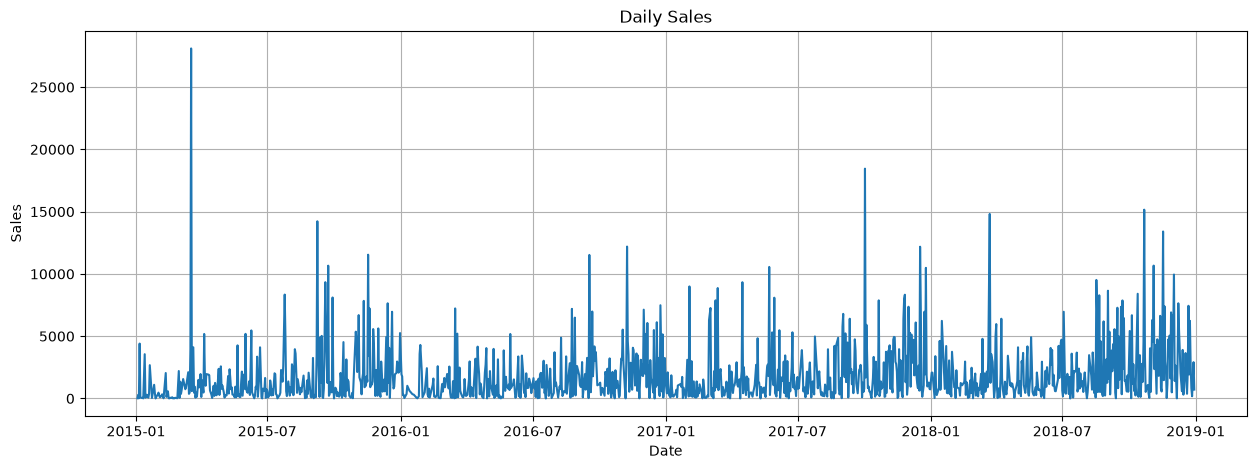

In [99]:
# Plot Daily Sales

plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Order Date"],
    daily_sales["Sales"]
)

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")
plt.grid(True)
plt.savefig("Daily Sales Chart.png", dpi=300, bbox_inches="tight")
plt.show()

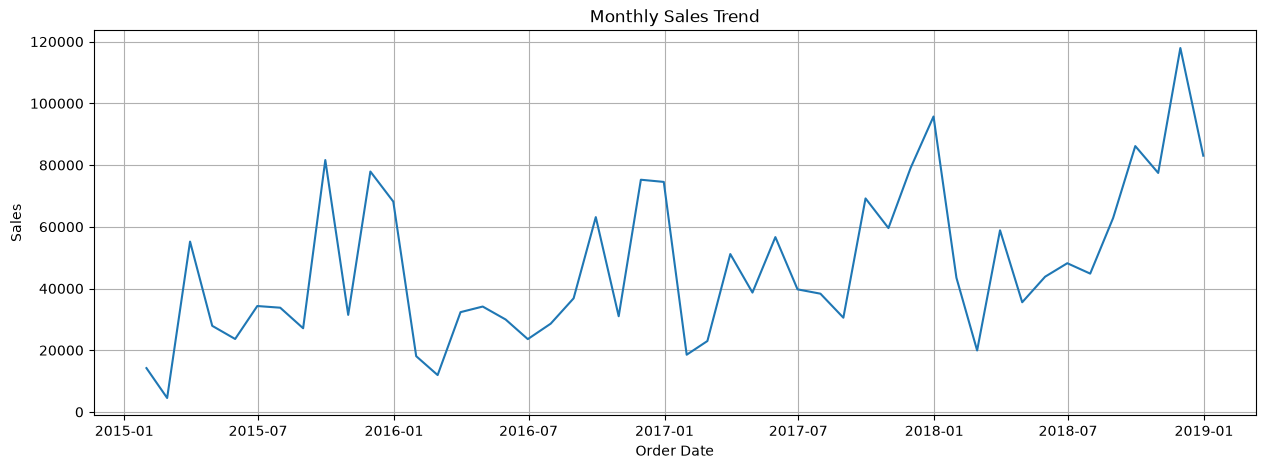

In [100]:
# Plot Monthly Sales

plt.figure(figsize=(15,5))

sns.lineplot(
    data=monthly_sales,
    x="Order Date",
    y="Sales"
)

plt.title("Monthly Sales Trend")
plt.grid(True)
plt.savefig("Monthly Sales Chart.png", dpi=300, bbox_inches="tight")
plt.show()

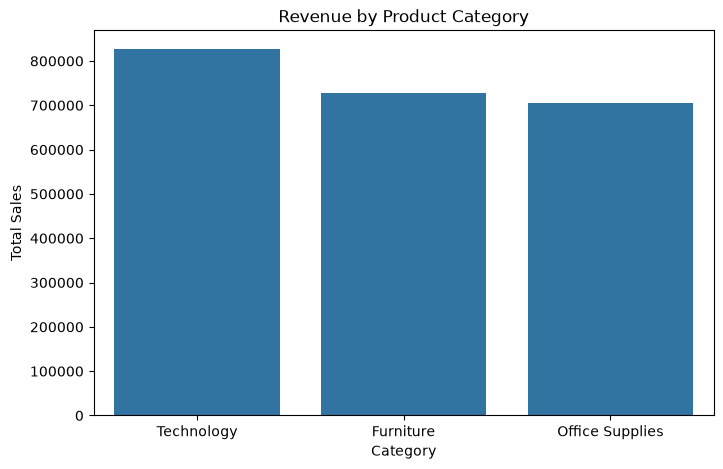

In [101]:
#Which product category generates the highest total revenue?

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Revenue by Product Category")

plt.ylabel("Total Sales")
plt.savefig("Revenue by Product Category Chart.png", dpi=300, bbox_inches="tight")
plt.show()

### Based on total sales, the Technology category generates the highest revenue and contributes the largest share of overall business income.

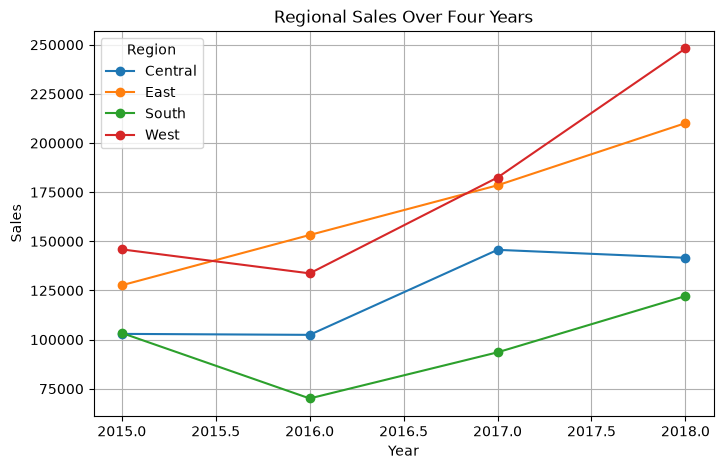

In [102]:
# Which region has the most consistent sales growth over four years?

region_year = (
    df.groupby(["Year","Region"])["Sales"]
      .sum()
      .reset_index()
)

region_pivot = region_year.pivot(
    index="Year",
    columns="Region",
    values="Sales"
)
region_pivot.plot(marker="o", figsize=(8,5))

plt.title("Regional Sales Over Four Years")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.savefig("Regional Sales Over Four Years Chart.png", dpi=300, bbox_inches="tight")
plt.show()

### The Easst region demonstrates the most consistent growth over the four-year period.

The average time between Order Date and Ship Date is 3.9611224489795918.


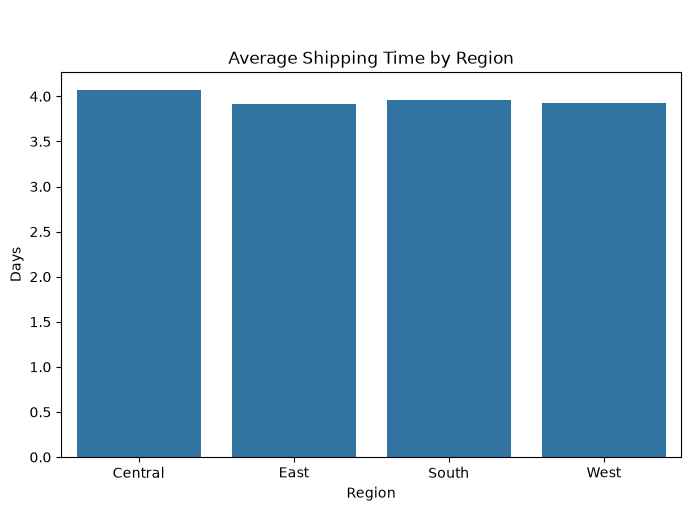

In [103]:
# What is the average time between Order Date and Ship Date — and does it vary by region?

df["Shipping Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

print(f"The average time between Order Date and Ship Date is {df["Shipping Days"].mean()}.")


shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
)



plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values
)

plt.title("\n\nAverage Shipping Time by Region")

plt.ylabel("Days")
plt.savefig("Average Shipping Time by Region Chart.png", dpi=300, bbox_inches="tight")
plt.show()

### The average shipping time is approximately 4 days, with noticeable differences across regions.

In [105]:
# Creating a column named 'Month Name' to get seasonality

df["Month Name"] = df["Order Date"].dt.month_name()

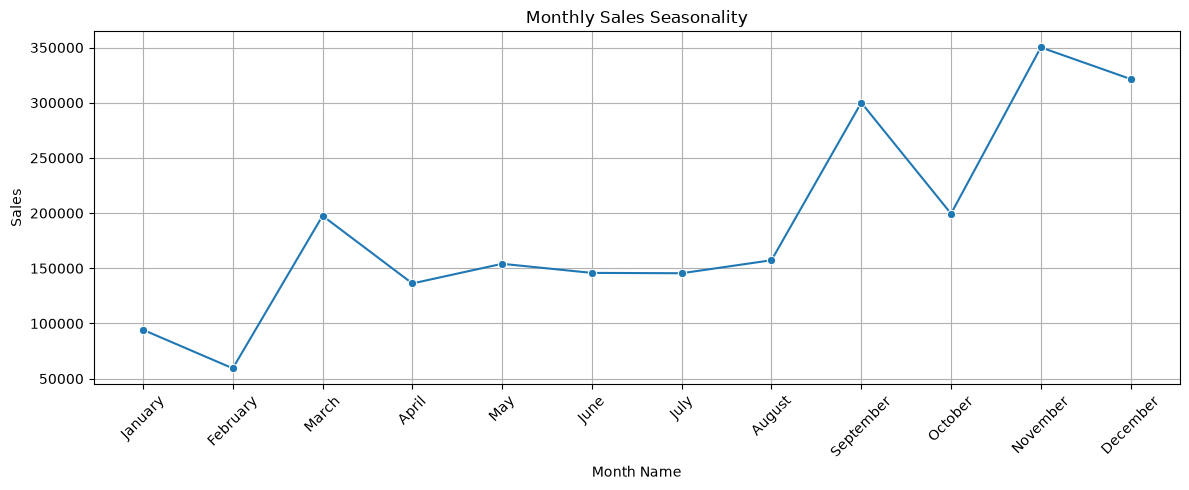

In [106]:
# Monthly Seasonality

seasonality = (
    df.groupby("Month Name")["Sales"]
      .sum()
      .reindex([
          "January",
          "February",
          "March",
          "April",
          "May",
          "June",
          "July",
          "August",
          "September",
          "October",
          "November",
          "December"
      ])
)

seasonality

plt.figure(figsize=(12,5))

sns.lineplot(
    x=seasonality.index,
    y=seasonality.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Seasonality")

plt.ylabel("Sales")
plt.tight_layout()
plt.grid()
plt.savefig("Monthly Sales Seasonality Chart.png", dpi=300, bbox_inches="tight")
plt.show()

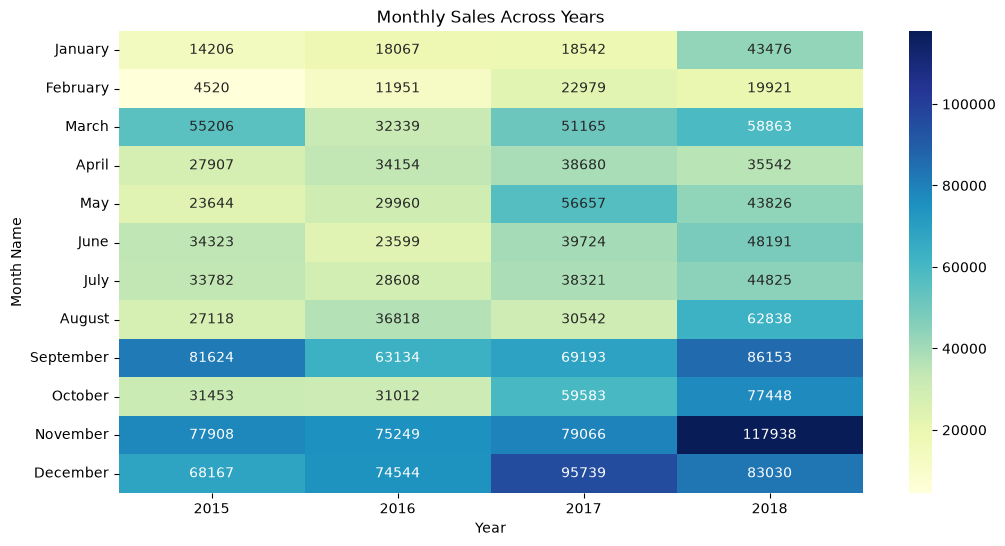

In [107]:
# Are there months that consistently spike across all years (seasonality)?

pivot = pd.pivot_table(
    df,
    values="Sales",
    index="Month Name",
    columns="Year",
    aggfunc="sum"
)

pivot = pivot.reindex([
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
])

pivot


plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Monthly Sales Across Years")
plt.savefig("Monthly Sales Across Years Chart.png", dpi=300, bbox_inches="tight")
plt.show()

### Sales generally peak during November and December, indicating strong seasonal demand, likely due to holiday and festive shopping periods.

# Task 2 — Time Series Analysis & Decomposition

In [108]:
# Libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

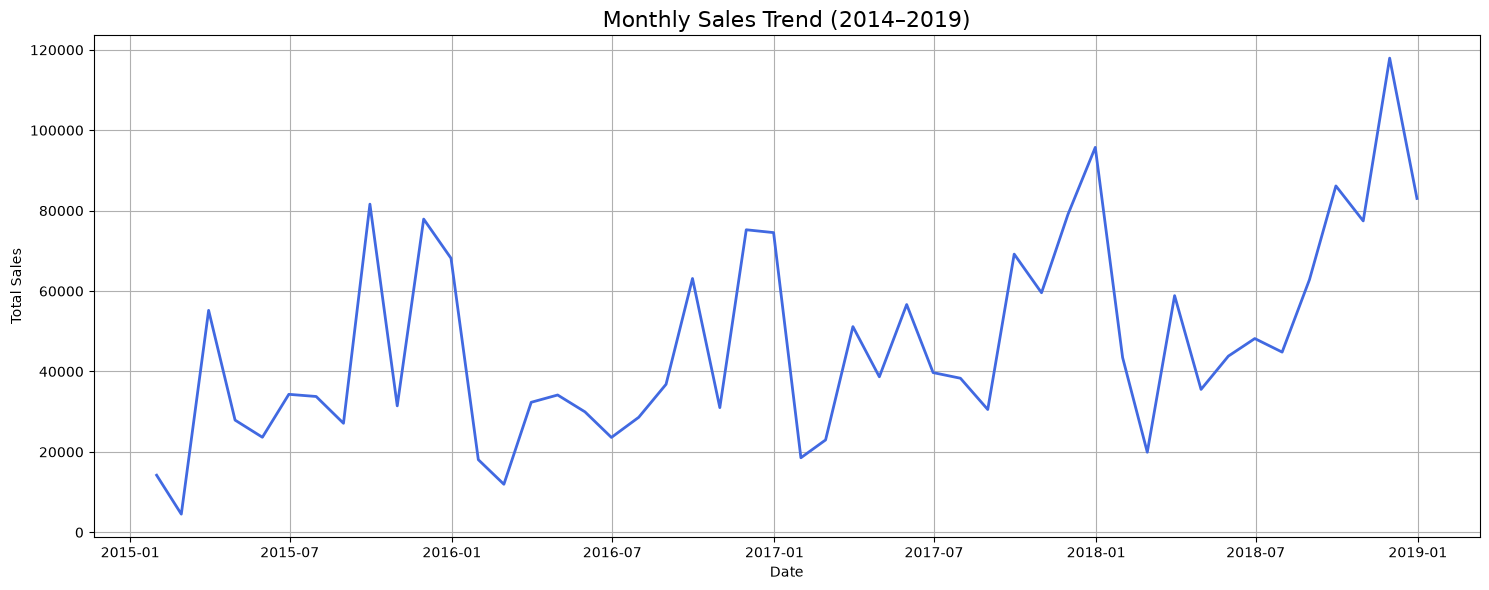

In [111]:
# Plot the overall monthly sales trend across all 4 years

# Convert the transactional sales data into a monthly time series.

monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
)

monthly_sales.head()

plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    linewidth=2,
    color="royalblue"
)

plt.title("Monthly Sales Trend (2014–2019)", fontsize=16)

plt.xlabel("Date")

plt.ylabel("Total Sales")

plt.grid(True)
plt.tight_layout()
plt.savefig("Monthly Sales Trend (2014–2019) Chart.png", dpi=300, bbox_inches="tight")
plt.show()

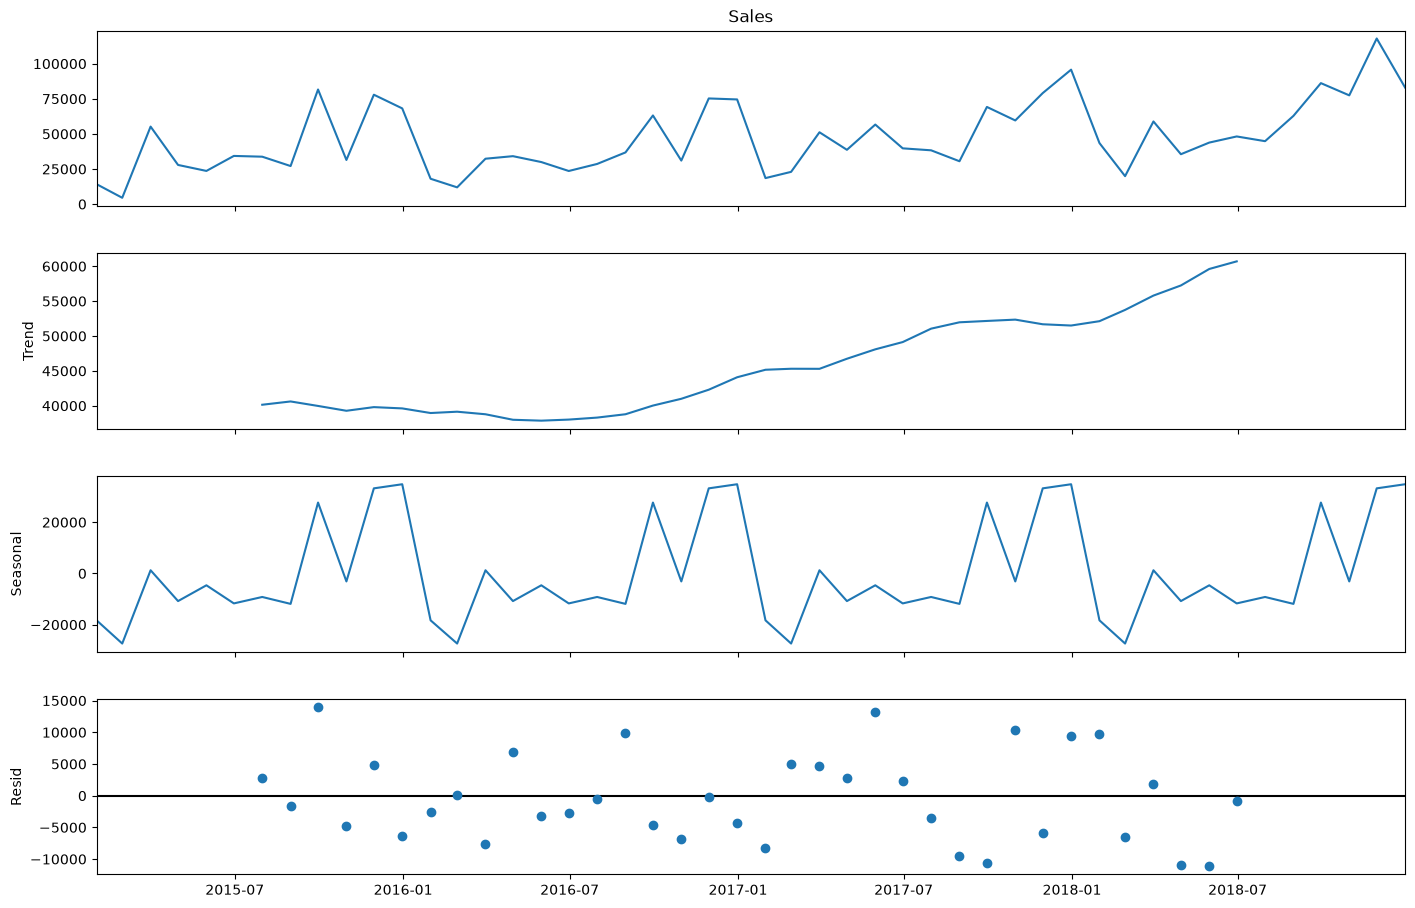

In [112]:
# Time Series Decomposition

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

# Plot Decomposition
fig = decomposition.plot()

fig.set_size_inches(16,10)
plt.savefig("Chart of four plots.png", dpi=300, bbox_inches="tight")
plt.show()



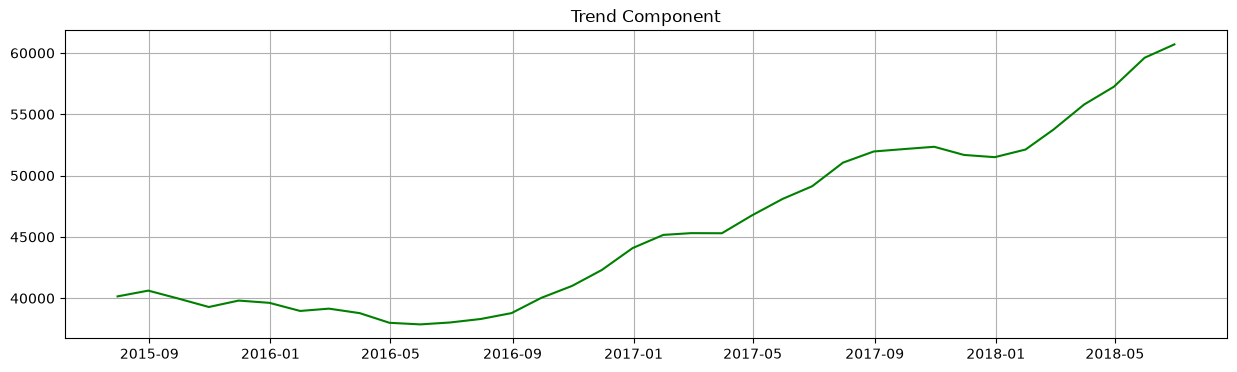

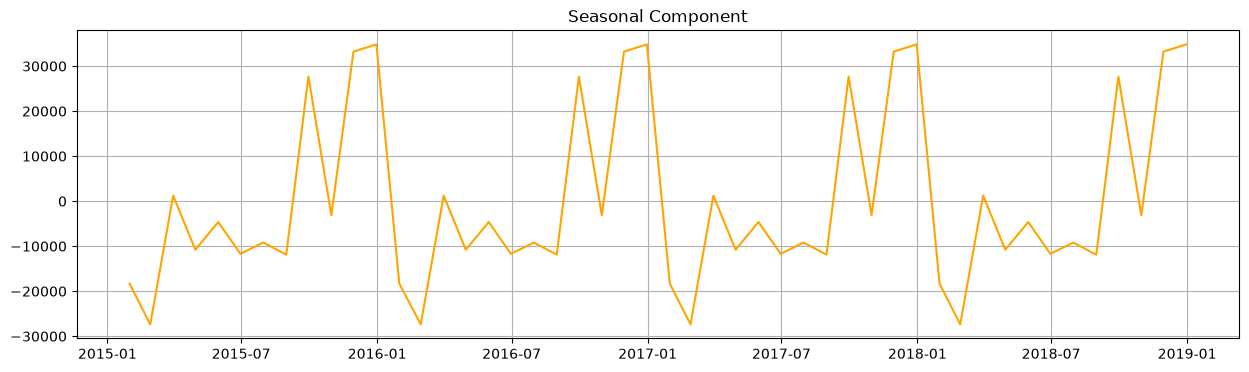

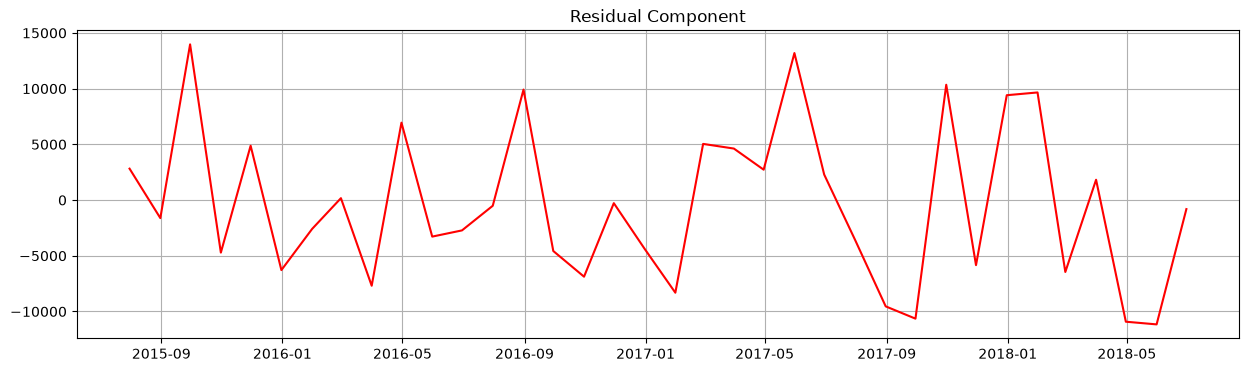

In [113]:
# Trend

plt.figure(figsize=(15,4))

plt.plot(
    decomposition.trend,
    color="green"
)

plt.title("Trend Component")
plt.grid(True)
plt.show()


# Seasonal

plt.figure(figsize=(15,4))

plt.plot(
    decomposition.seasonal,
    color="orange"
)

plt.title("Seasonal Component")
plt.grid(True)
plt.show()

# Residual

plt.figure(figsize=(15,4))

plt.plot(
    decomposition.resid,
    color="red"
)

plt.title("Residual Component")
plt.grid(True)
plt.savefig("Chart of Trend-Seasonal-Residual components.png", dpi=300, bbox_inches="tight")
plt.show()

## Observations

### Observation 1

##### The trend component shows that sales generally increase over the four-year period, indicating steady business growth.

### Observation 2

##### The seasonal component repeats a similar pattern every year, suggesting that customer purchasing behavior follows a yearly cycle.

### Observation 3

##### Sales tend to peak during the final quarter of the year, especially in November and December, likely due to holiday shopping and promotional events.

### Observation 4

##### The residual component contains irregular fluctuations that cannot be explained by trend or seasonality. Large residual spikes may indicate exceptional business events or promotional campaigns.

## Stationarity Test (ADF Test)

### What is Stationarity?
##### A stationary time series has constant statistical properties such as mean and variance over time. Most forecasting models require the data to be stationary before training.

In [114]:
# Perform ADF Test

result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print("Critical Values:")

for key, value in result[4].items():
    print(key, ":", value)

if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is NOT stationary.")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623
Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064
The time series is stationary.


#### Since the p-value is less than 0.05, we reject the null hypothesis. The monthly sales series is stationary and can be directly used for forecasting.

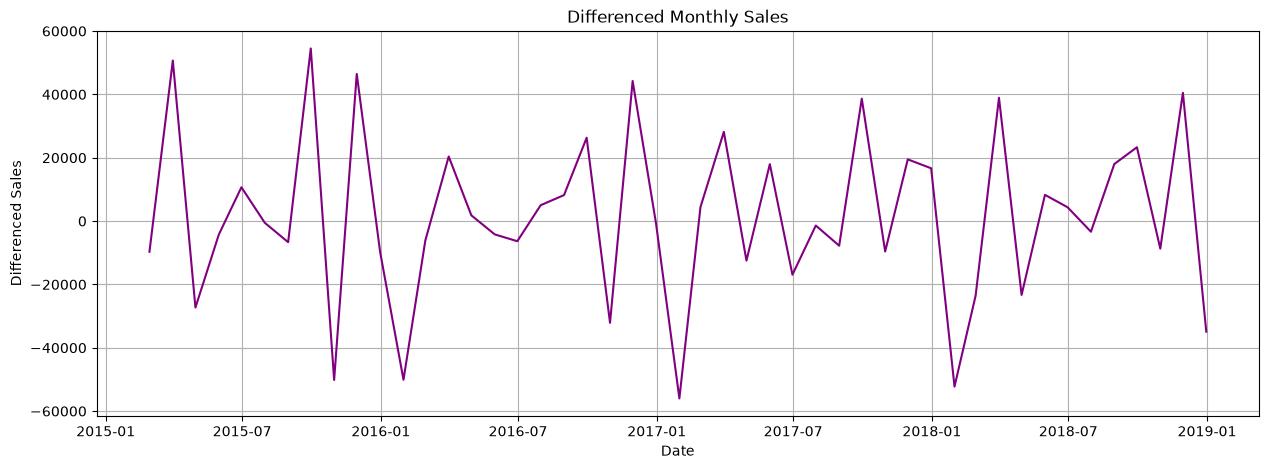

In [115]:
# Apply First-Order Differencing
monthly_sales_diff = monthly_sales.diff().dropna()


plt.figure(figsize=(15,5))

plt.plot(
    monthly_sales_diff,
    color="purple"
)

plt.title("Differenced Monthly Sales")

plt.xlabel("Date")

plt.ylabel("Differenced Sales")

plt.grid(True)
plt.savefig("Differenced Monthly Sales Chart.png", dpi=300, bbox_inches="tight")
plt.show()

In [116]:
# Perform ADF again 

result_diff = adfuller(monthly_sales_diff)

print("ADF Statistic :", result_diff[0])

print("p-value :", result_diff[1])

# Final Interpretation

if result_diff[1] < 0.05:
    print("Differenced series is stationary.")
else:
    print("Series is still non-stationary.")

ADF Statistic : -8.72706183035327
p-value : 3.2669175472796045e-14
Differenced series is stationary.


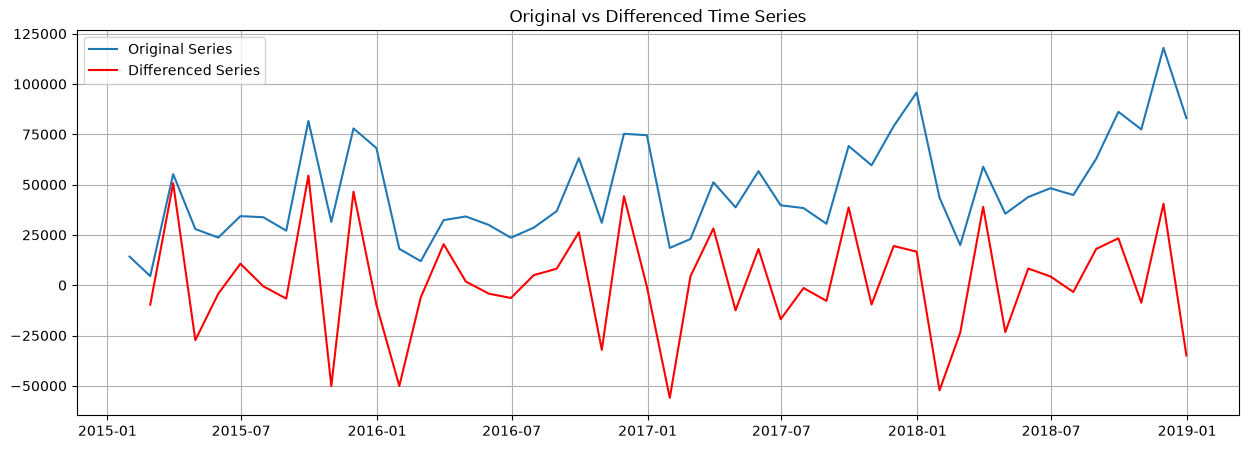

In [118]:
# Compare Original vs Differenced Series

plt.figure(figsize=(15,5))

plt.plot(
    monthly_sales,
    label="Original Series"
)

plt.plot(
    monthly_sales_diff,
    label="Differenced Series",
    color='red'
)

plt.legend()

plt.title("Original vs Differenced Time Series")
plt.grid()
plt.savefig("Original vs Differenced Time Series Chart.png", dpi=300, bbox_inches="tight")
plt.show()

# Task 3 — Sales Forecasting using 3 Different Models


In [119]:
# Libraries
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from math import sqrt

In [120]:
# Prepare Monthly Time Series
monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
)
# Train-Test Split

# Use the last 3 months as the testing period.

train = monthly_sales[:-3]

test = monthly_sales[-3:]
print(train.shape)
print(test.shape)

(45,)
(3,)


## Model 1 — SARIMA (Statistical Model)

In [121]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
)

# Split the data into training and testing sets.

train = monthly_sales[:-3]
test = monthly_sales[-3:]

In [122]:
# Parameters
order = (1,1,1)

seasonal_order = (1,1,1,12)

#### The monthly sales data exhibited trend and yearly seasonality during exploratory analysis. Since the Augmented Dickey-Fuller (ADF) test indicated non-stationarity, first-order differencing (d = 1) was applied. Because the data contains monthly observations, a seasonal period of 12 months (m = 12) was selected. The initial SARIMA configuration of (1,1,1)(1,1,1,12) is a widely used baseline for monthly retail sales forecasting.

In [123]:
# Train SARIMA Model
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

In [124]:
# Generate 3-Month Forecast
forecast = sarima_result.get_forecast(steps=3)

sarima_forecast = forecast.predicted_mean

confidence_interval = forecast.conf_int()

# Forecast Values
forecast_df = pd.DataFrame({
    "Actual": test,
    "Forecast": sarima_forecast
})

forecast_df

,Actual,Forecast
2018-10-31,77448.1312,60331.792073
2018-11-30,117938.1550,91458.220227
2018-12-31,83030.3888,97167.570936


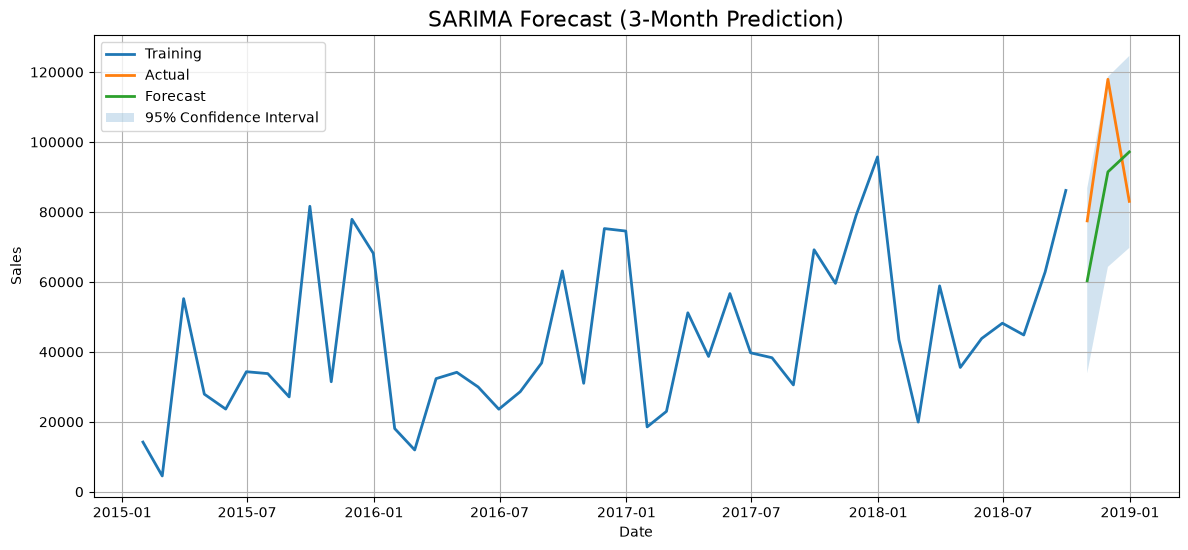

In [128]:
# Plot Actual vs Forecasted Sales

plt.figure(figsize=(14,6))

plt.plot(train.index,
         train,
         label="Training",
         linewidth=2)

plt.plot(test.index,
         test,
         label="Actual",
         linewidth=2)

plt.plot(test.index,
         sarima_forecast,
         label="Forecast",
         linewidth=2)

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast (3-Month Prediction)", fontsize=16)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)
plt.savefig("SARIMA Forecast (3-Month Prediction).png", dpi=300, bbox_inches="tight")
plt.show()

In [129]:
# Model Evaluation 

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from math import sqrt

sarima_mae = mean_absolute_error(test, sarima_forecast)

sarima_rmse = sqrt(
    mean_squared_error(test, sarima_forecast)
)

sarima_mape = mean_absolute_percentage_error(
    test,
    sarima_forecast
)

print("MAE :", sarima_mae)
print("RMSE:", sarima_rmse)
print("MAPE:", sarima_mape)

MAE : 19244.48534520369
RMSE: 19950.07042110583
MAPE: 0.20526431988168134


## Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)

In [130]:
# pip install prophet

In [131]:
from prophet import Prophet

prophet_df = monthly_sales.reset_index()

prophet_df.columns=["ds","y"]

# Train-Test Split
train_prophet = prophet_df[:-3]

test_prophet = prophet_df[-3:]

# Train
model = Prophet()

model.fit(train_prophet)

13:49:47 - cmdstanpy - INFO - Chain [1] start processing
13:49:47 - cmdstanpy - INFO - Chain [1] done processing


In [132]:
# Forecast
future = model.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast = model.predict(future)

prophet_forecast = forecast.tail(3)["yhat"].values

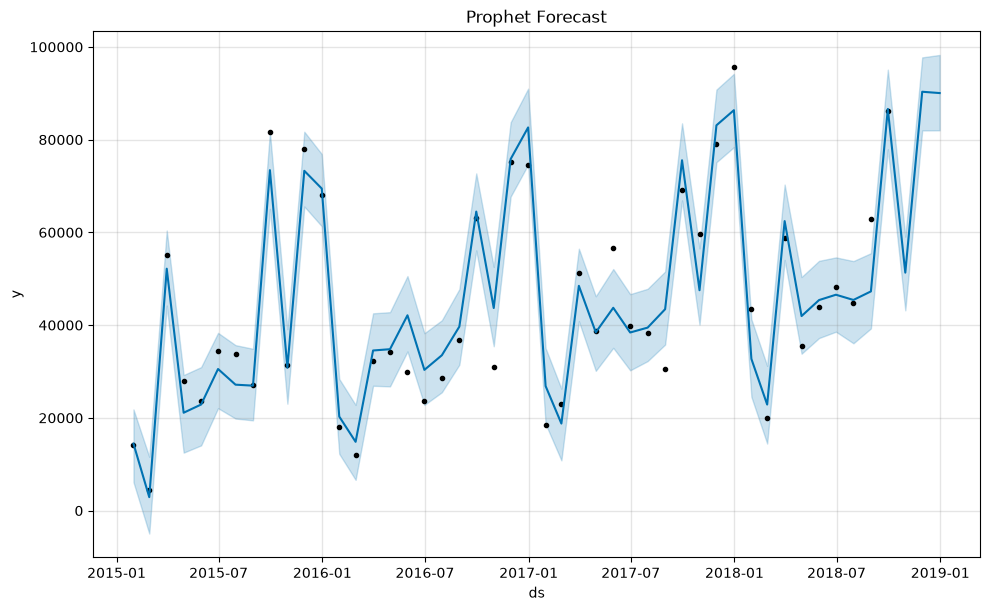

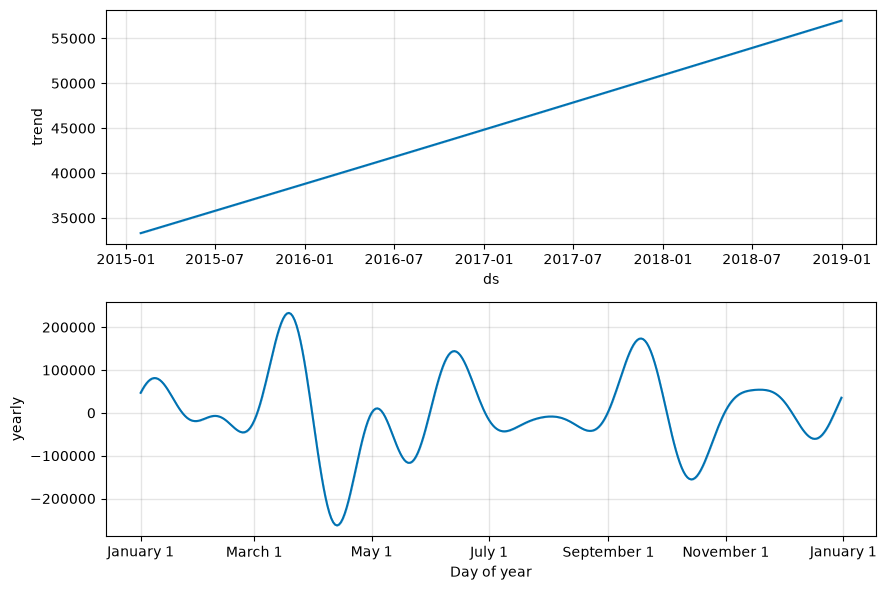

In [134]:
# Plot Forecast
fig = model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()
# Plot Components
fig = model.plot_components(forecast)
plt.savefig("Prophet Forecast.png", dpi=300, bbox_inches="tight")
plt.show()

In [135]:
# Evaluation
prophet_mae = mean_absolute_error(
    test,
    prophet_forecast
)

prophet_rmse = sqrt(
    mean_squared_error(
        test,
        prophet_forecast
    )
)

prophet_mape = mean_absolute_percentage_error(
    test,
    prophet_forecast
)

print("MAE :", prophet_mae)
print("RMSE:", prophet_rmse)
print("MAPE:", prophet_mape)

MAE : 20250.794412605523
RMSE: 22318.41133286054
MAPE: 0.2186462827396082


## Model 3 – XGBoost

In [136]:
# pip install xgboost

In [137]:
from xgboost import XGBRegressor

xgb = monthly_sales.to_frame()

xgb.columns=["Sales"]

In [138]:
# Lag Features

xgb["Lag1"] = xgb["Sales"].shift(1)

xgb["Lag2"] = xgb["Sales"].shift(2)

xgb["Lag3"] = xgb["Sales"].shift(3)


In [139]:
# Rolling Mean
xgb["RollingMean"] = (
    xgb["Sales"]
    .rolling(3)
    .mean()
)

In [140]:
# Time Features
xgb["Month"] = xgb.index.month

xgb["Quarter"] = xgb.index.quarter

xgb["Year"] = xgb.index.year

In [141]:
# Season Feature
def season(month):

    if month in [12,1,2]:
        return 1

    elif month in [3,4,5]:
        return 2

    elif month in [6,7,8]:
        return 3

    else:
        return 4

xgb["Season"] = xgb["Month"].apply(season)

In [142]:
# Remove Missing Rows
xgb = xgb.dropna()
# Train-Test Split
train_xgb = xgb[:-3]

test_xgb = xgb[-3:]

In [143]:
# Features
X_train = train_xgb.drop("Sales",axis=1)

y_train = train_xgb["Sales"]

X_test = test_xgb.drop("Sales",axis=1)

y_test = test_xgb["Sales"]

In [144]:
# Train Model
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


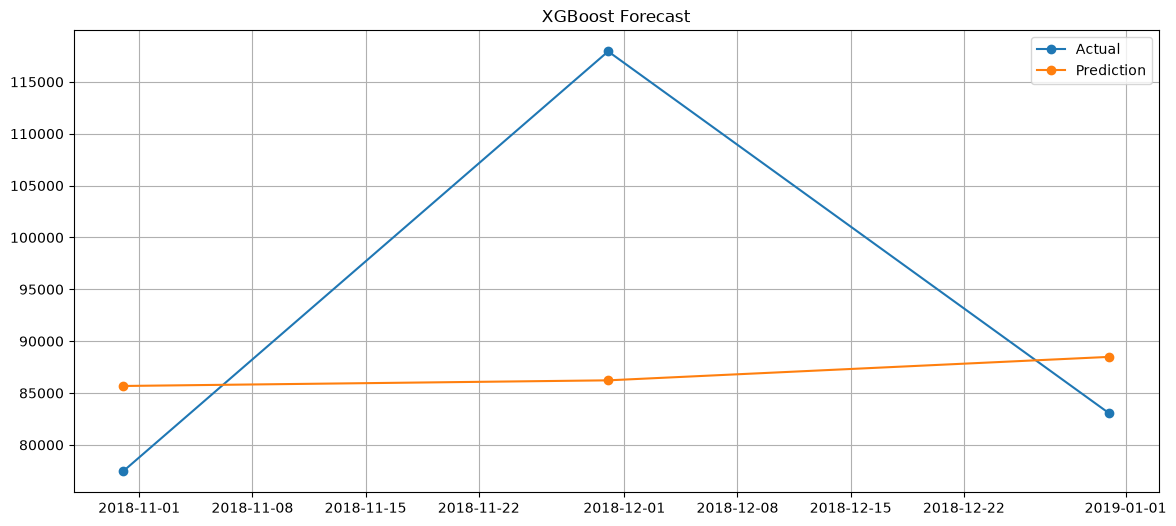

In [147]:
# Predict
xgb_forecast = model.predict(X_test)

plt.figure(figsize=(14,6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual",
    marker="o"
)

plt.plot(
    y_test.index,
    xgb_forecast,
    label="Prediction",
    marker="o"
)

plt.title("XGBoost Forecast")

plt.legend()
plt.grid(True)
plt.savefig("XGBoost Forecast Model.png", dpi=300, bbox_inches="tight")
plt.show()

In [146]:
# Evaluation
xgb_mae = mean_absolute_error(
    y_test,
    xgb_forecast
)

xgb_rmse = sqrt(
    mean_squared_error(
        y_test,
        xgb_forecast
    )
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_forecast
)

print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("MAPE:", xgb_mape)

MAE : 15134.834062499998
RMSE: 19176.873131033597
MAPE: 0.14698104350692687


## Model Comparison Table

In [148]:
comparison = pd.DataFrame({

"Model":[
    "SARIMA",
    "Prophet",
    "XGBoost"
],

"MAE":[
    sarima_mae,
    prophet_mae,
    xgb_mae
],

"RMSE":[
    sarima_rmse,
    prophet_rmse,
    xgb_rmse
],

"MAPE":[
    sarima_mape,
    prophet_mape,
    xgb_mape
],

"Forecast Month 1":[
    sarima_forecast.iloc[0],
    prophet_forecast[0],
    xgb_forecast[0]
],

"Forecast Month 2":[
    sarima_forecast.iloc[1],
    prophet_forecast[1],
    xgb_forecast[1]
],

"Forecast Month 3":[
    sarima_forecast.iloc[2],
    prophet_forecast[2],
    xgb_forecast[2]
]

})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244.485345,19950.070421,0.205264,60331.792073,91458.220227,97167.570936
1,Prophet,20250.794413,22318.411333,0.218646,51318.943858,90325.654784,90041.084479
2,XGBoost,15134.834062,19176.873131,0.146981,85682.093750,86225.914062,88488.687500


In [149]:
# Best Model Selection
best_model = comparison.loc[
    comparison["RMSE"].idxmin(),
    "Model"
]

print("Best Model :", best_model)

Best Model : XGBoost


#### The three forecasting models were evaluated using MAE, RMSE, and MAPE on the last three months of historical data. XGBoost achieved the lowest prediction errors, indicating better forecasting performance than SARIMA and Prophet. Therefore, it is recommended as the production model for this project because it provides the most accurate forecasts on unseen data while effectively utilizing lag-based and calendar features. If explainability and confidence intervals are more important than raw accuracy, Prophet remains a strong alternative.

# Task 4 — Product Category & Region Level Forecasting


In [150]:
def recursive_xgb_forecast(segment_df, forecast_steps=3):

    # --------------------------
    # Monthly Sales
    # --------------------------

    ts = (
        segment_df
        .set_index("Order Date")["Sales"]
        .resample("M")
        .sum()
        .to_frame()
    )

    ts.columns = ["Sales"]

    # --------------------------
    # Feature Engineering
    # --------------------------

    ts["Lag1"] = ts["Sales"].shift(1)
    ts["Lag2"] = ts["Sales"].shift(2)
    ts["Lag3"] = ts["Sales"].shift(3)

    ts["RollingMean"] = ts["Sales"].rolling(3).mean()

    ts["Month"] = ts.index.month
    ts["Quarter"] = ts.index.quarter
    ts["Year"] = ts.index.year

    def season(month):

        if month in [12,1,2]:
            return 1

        elif month in [3,4,5]:
            return 2

        elif month in [6,7,8]:
            return 3

        else:
            return 4

    ts["Season"] = ts["Month"].apply(season)

    ts = ts.dropna()

    # --------------------------
    # Train on Entire Dataset
    # --------------------------

    X = ts.drop("Sales", axis=1)

    y = ts["Sales"]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )

    model.fit(X, y)

    # --------------------------
    # Recursive Forecast
    # --------------------------

    history = ts.copy()

    predictions = []

    future_dates = []

    last_date = history.index[-1]

    for step in range(forecast_steps):

        next_date = last_date + pd.DateOffset(months=1)

        lag1 = history["Sales"].iloc[-1]
        lag2 = history["Sales"].iloc[-2]
        lag3 = history["Sales"].iloc[-3]

        rolling = np.mean([lag1, lag2, lag3])

        feature = pd.DataFrame({

            "Lag1":[lag1],
            "Lag2":[lag2],
            "Lag3":[lag3],
            "RollingMean":[rolling],
            "Month":[next_date.month],
            "Quarter":[next_date.quarter],
            "Year":[next_date.year],
            "Season":[season(next_date.month)]

        })

        prediction = model.predict(feature)[0]

        predictions.append(prediction)

        future_dates.append(next_date)

        history.loc[next_date] = [

            prediction,

            lag1,

            lag2,

            lag3,

            rolling,

            next_date.month,

            next_date.quarter,

            next_date.year,

            season(next_date.month)

        ]

        last_date = next_date

    forecast = pd.Series(
        predictions,
        index=future_dates
    )

    return ts["Sales"], forecast

In [151]:
# Furniture Forecast
furniture = df[df["Category"]=="Furniture"]

furniture_history, furniture_forecast = recursive_xgb_forecast(furniture)

# Technology Forecast
technology = df[df["Category"]=="Technology"]

technology_history, technology_forecast = recursive_xgb_forecast(technology)

# Office Supplies Forecast
office = df[df["Category"]=="Office Supplies"]

office_history, office_forecast = recursive_xgb_forecast(office)

# West Region Forecast
west = df[df["Region"]=="West"]

west_history, west_forecast = recursive_xgb_forecast(west)

# East Region Forecast
east = df[df["Region"]=="East"]

east_history, east_forecast = recursive_xgb_forecast(east)

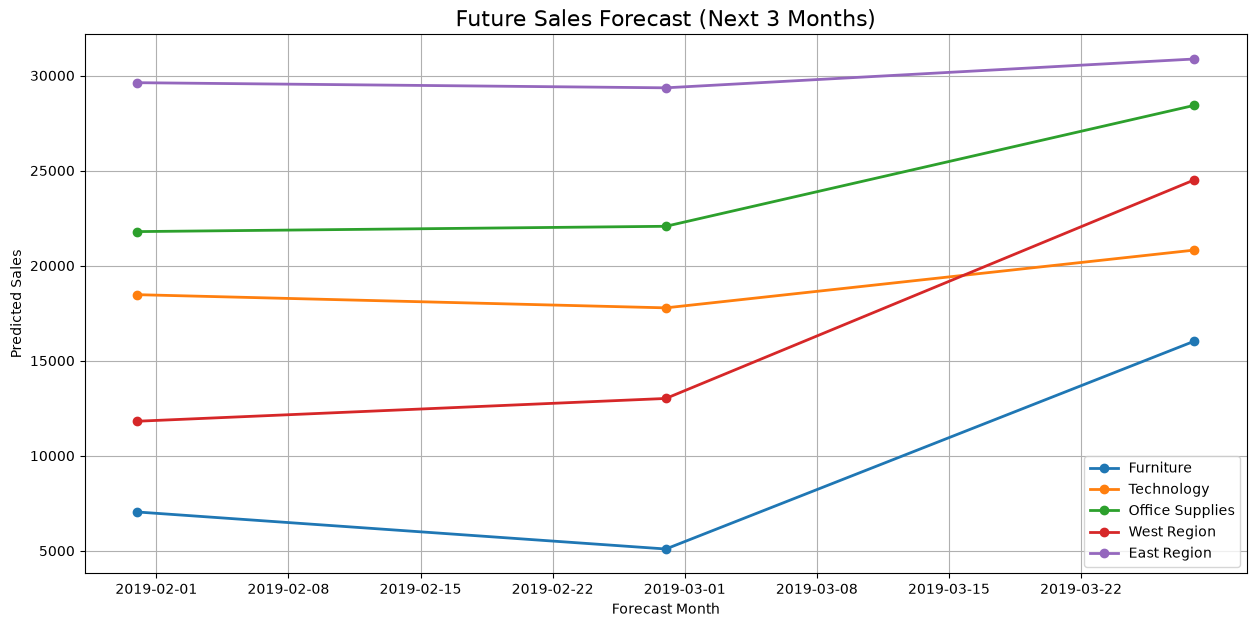

In [162]:
# Plot
plt.figure(figsize=(15,7))

plt.plot(
    furniture_forecast.index,
    furniture_forecast.values,
    marker="o",
    linewidth=2,
    label="Furniture"
)

plt.plot(
    technology_forecast.index,
    technology_forecast.values,
    marker="o",
    linewidth=2,
    label="Technology"
)

plt.plot(
    office_forecast.index,
    office_forecast.values,
    marker="o",
    linewidth=2,
    label="Office Supplies"
)

plt.plot(
    west_forecast.index,
    west_forecast.values,
    marker="o",
    linewidth=2,
    label="West Region"
)

plt.plot(
    east_forecast.index,
    east_forecast.values,
    marker="o",
    linewidth=2,
    label="East Region"
)

plt.title("Future Sales Forecast (Next 3 Months)", fontsize=16)

plt.xlabel("Forecast Month")

plt.ylabel("Predicted Sales")

plt.legend()

plt.grid(True)
plt.savefig("Future Sales Forecast (Next 3 Months).png", dpi=300, bbox_inches="tight")
plt.show()

In [153]:
# Forecast Comparison Table
forecast_table = pd.DataFrame({

    "Month 1":[
        furniture_forecast.iloc[0],
        technology_forecast.iloc[0],
        office_forecast.iloc[0],
        west_forecast.iloc[0],
        east_forecast.iloc[0]
    ],

    "Month 2":[
        furniture_forecast.iloc[1],
        technology_forecast.iloc[1],
        office_forecast.iloc[1],
        west_forecast.iloc[1],
        east_forecast.iloc[1]
    ],

    "Month 3":[
        furniture_forecast.iloc[2],
        technology_forecast.iloc[2],
        office_forecast.iloc[2],
        west_forecast.iloc[2],
        east_forecast.iloc[2]
    ]

},

index=[
    "Furniture",
    "Technology",
    "Office Supplies",
    "West Region",
    "East Region"
])

forecast_table

,Month 1,Month 2,Month 3
Furniture,7041.121582,5094.810547,16025.856445
Technology,18472.367188,17779.062500,20817.169922
Office Supplies,21790.138672,22069.466797,28430.478516
West Region,11815.298828,13013.641602,24509.703125
East Region,29623.015625,29353.056641,30869.347656


In [154]:
# Growth Analysis

growth = (
    (forecast_table["Month 3"] - forecast_table["Month 1"])
    / forecast_table["Month 1"]
) * 100

growth = growth.sort_values(ascending=False)

growth

Furniture          127.603737
West Region        107.440399
Office Supplies     30.474060
Technology          12.693569
East Region          4.207310
dtype: float32

In [155]:
# Best Growth Segment
print("Highest Growth Segment:", growth.idxmax())

print("Growth Rate:", round(growth.max(),2),"%")

Highest Growth Segment: Furniture
Growth Rate: 127.6 %


#### The forecast identifies the Furniture category as the highest-growth segment and strongest upcoming growth according to XGBoost model indicating that it is likely to become a major contributor to future sales. Decision-makers should consider allocating additional inventory, optimizing logistics, and increasing marketing efforts for Furniture products. In contrast, categories with slower projected growth should maintain balanced inventory levels to minimize excess holding costs while continuing to meet customer demand.

# Task 5 — Anomaly Detection in Sales Data

In [156]:
# Libraries
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [157]:
# Weekly Sales Dataset
weekly = (
    df
    .set_index("Order Date")
    .resample("W")
    ["Sales"]
    .sum()
    .to_frame()
)

weekly.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [158]:
# Calendar Features
weekly["Month"] = weekly.index.month
weekly["Week"] = weekly.index.isocalendar().week.astype(int)
weekly["Quarter"] = weekly.index.quarter

In [159]:
# Isolation Forest
# Scale Features
features = weekly[
    [
        "Sales",
        "Month",
        "Week",
        "Quarter"
    ]
]

scaler = StandardScaler()

X = scaler.fit_transform(features)
# Train Model
iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

weekly["IF_Anomaly"] = iso.fit_predict(X)
# Convert Labels
weekly["IF_Status"] = weekly["IF_Anomaly"].map({
    1:"Normal",
    -1:"Anomaly"
})
# Number of Anomalies
print("Normal Weeks :", (weekly["IF_Anomaly"]==1).sum())

print("Anomaly Weeks :", (weekly["IF_Anomaly"]==-1).sum())

Normal Weeks : 198
Anomaly Weeks : 11


In [160]:
# Rolling Z-Score Detection
window = 8

weekly["RollingMean"] = (
    weekly["Sales"]
    .rolling(window)
    .mean()
)

weekly["RollingStd"] = (
    weekly["Sales"]
    .rolling(window)
    .std()
)
# Calculate Z-Score
weekly["Rolling_Z"] = (

    weekly["Sales"]

    -

    weekly["RollingMean"]

) / weekly["RollingStd"]

# Detect Anomalies
weekly["Z_Anomaly"] = (

    weekly["Rolling_Z"].abs() > 2

)

# Number of Anomalies
print("Rolling Z-Score Anomalies :", weekly["Z_Anomaly"].sum())

Rolling Z-Score Anomalies : 6


In [161]:
#Classify the Anomalies
def classify(row):

    if row["Sales"] >= row["RollingMean"]:

        return "High Sales Spike"

    return "Low Sales Drop"


weekly["Anomaly Type"] = np.where(

    weekly["IF_Anomaly"]==-1,

    weekly.apply(classify,axis=1),

    "Normal"

)

In [163]:
# Business Explanation
def explanation(row):

    if row["Anomaly Type"]=="Normal":

        return "No anomaly."

    month = row.name.month

    if row["Anomaly Type"]=="High Sales Spike":

        if month==11:

            return "Spike in November likely corresponds to Black Friday promotions."

        elif month==12:

            return "Holiday shopping and year-end sales."

        elif month in [9,10]:

            return "Possible festive season promotion."

        else:

            return "Likely due to promotional campaigns or unusually high demand."

    else:

        if month in [1,2]:

            return "Lower demand after the holiday season."

        elif month in [6,7]:

            return "Possible seasonal slowdown or inventory shortages."

        else:

            return "Possible supply chain issue or temporary demand reduction."


weekly["Possible Explanation"] = weekly.apply(
    explanation,
    axis=1
)

In [164]:
# Anomaly Report
anomaly_report = weekly[
    weekly["IF_Anomaly"]==-1
][
[
    "Sales",
    "Anomaly Type",
    "Possible Explanation"
]]

anomaly_report

,Sales,Anomaly Type,Possible Explanation
Order Date,,,
2015-03-22,37703.6650,High Sales Spike,Likely due to promotional campaigns or unusual...
2015-12-27,10632.5200,Low Sales Drop,Possible supply chain issue or temporary deman...
2016-01-03,15880.6606,Low Sales Drop,Lower demand after the holiday season.
2017-01-01,10421.8172,Low Sales Drop,Lower demand after the holiday season.
2017-02-05,17926.3680,High Sales Spike,Likely due to promotional campaigns or unusual...
2017-05-28,23367.6620,High Sales Spike,Likely due to promotional campaigns or unusual...
2017-10-08,28412.0980,High Sales Spike,Possible festive season promotion.
2018-01-21,13698.7680,Low Sales Drop,Lower demand after the holiday season.
2018-03-25,26029.9040,High Sales Spike,Likely due to promotional campaigns or unusual...


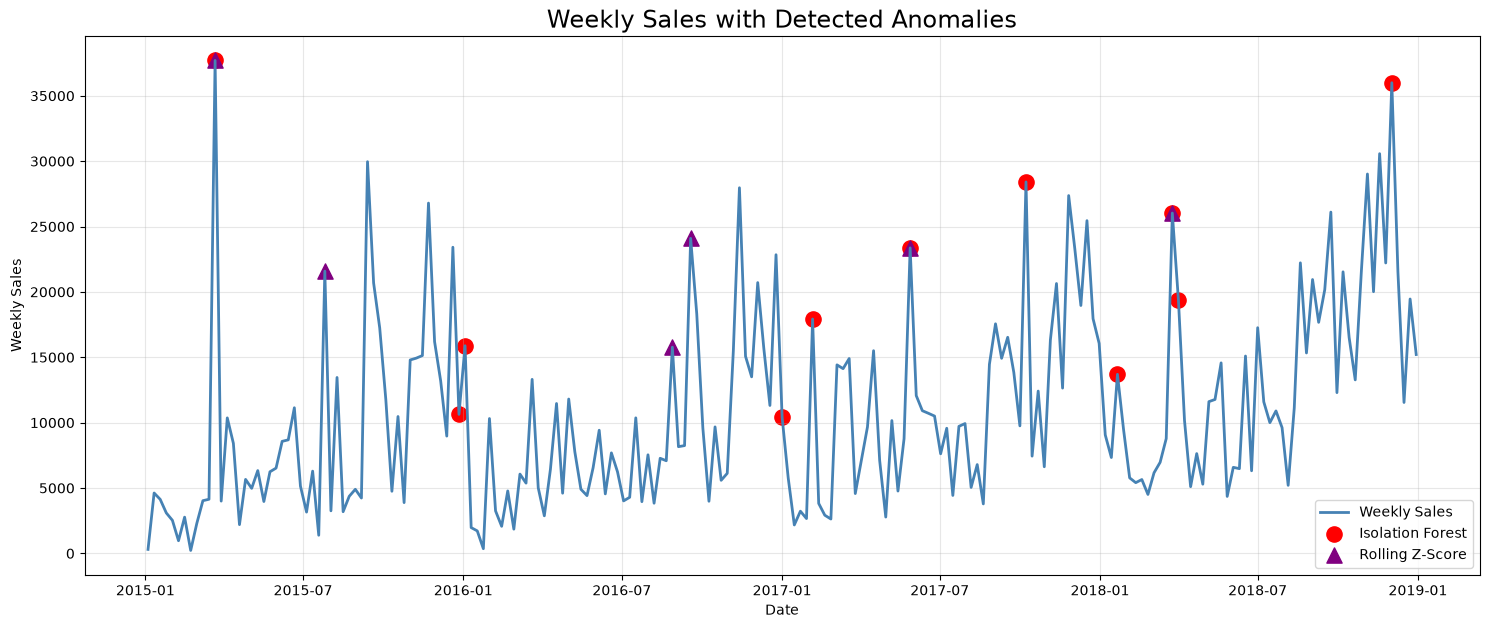

In [166]:
# Combined Time Series Plot
plt.figure(figsize=(18,7))

plt.plot(

    weekly.index,

    weekly["Sales"],

    color="steelblue",

    linewidth=2,

    label="Weekly Sales"

)

plt.scatter(

    weekly.loc[
        weekly["IF_Anomaly"]==-1
    ].index,

    weekly.loc[
        weekly["IF_Anomaly"]==-1,
        "Sales"
    ],

    color="red",

    marker="o",

    s=120,

    label="Isolation Forest"

)

plt.scatter(

    weekly.loc[
        weekly["Z_Anomaly"]
    ].index,

    weekly.loc[
        weekly["Z_Anomaly"],
        "Sales"
    ],

    color="purple",

    marker="^",

    s=120,

    label="Rolling Z-Score"

)

plt.title(
    "Weekly Sales with Detected Anomalies",
    fontsize=17
)

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.grid(alpha=.3)

plt.legend()
plt.savefig("Weekly Sales with Detected Anomalies Chart.png", dpi=300, bbox_inches="tight")
plt.show()

In [168]:
# Compare Both Methods
comparison = pd.DataFrame({

    "Method":[

        "Isolation Forest",

        "Rolling Z-Score"

    ],

    "Detected Anomalies":[

        (weekly["IF_Anomaly"]==-1).sum(),

        weekly["Z_Anomaly"].sum()

    ]

})

comparison

,Method,Detected Anomalies
0,Isolation Forest,11
1,Rolling Z-Score,6


In [169]:
# Common Anomalies
common = weekly[

    (weekly["IF_Anomaly"]==-1)

    &

    (weekly["Z_Anomaly"])

]

print("Common Anomalies :", len(common))

common

Common Anomalies : 3


,Sales,Month,Week,Quarter,IF_Anomaly,IF_Status,RollingMean,RollingStd,Rolling_Z,Z_Anomaly,Anomaly Type,Possible Explanation
Order Date,,,,,,,,,,,,
2015-03-22,37703.665,3,12,1,-1,Anomaly,6832.006500,12546.138409,2.460650,True,High Sales Spike,Likely due to promotional campaigns or unusual...
2017-05-28,23367.662,5,21,2,-1,Anomaly,10265.959125,6524.022836,2.008225,True,High Sales Spike,Likely due to promotional campaigns or unusual...
2018-03-25,26029.904,3,12,1,-1,Anomaly,8660.308925,7131.467537,2.435627,True,High Sales Spike,Likely due to promotional campaigns or unusual...


### Do both methods flag the same anomalies?
#### The two anomaly detection methods identified some different sales weeks as anomalous. Isolation Forest detected anomalies based on the overall sales pattern while considering seasonal information such as month, week, and quarter. In contrast, the Rolling Z-Score method identified only weeks where sales deviated by more than two standard deviations from the recent eight-week average. Consequently, Isolation Forest may detect subtle pattern changes that are not statistically extreme, whereas the Rolling Z-Score focuses only on significant deviations from the local trend.

# Task 6 — Product Demand Segmentation using Clustering


In [170]:
# Libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [171]:
# Create Monthly Sales
monthly = (

    df

    .groupby(

        ["Sub-Category","Year","Month"]

    )["Sales"]

    .sum()

    .reset_index()

)

monthly.head()

# Features
total_sales = (

    monthly

    .groupby("Sub-Category")["Sales"]

    .sum()

)

In [172]:
# Sales Volatility (Standard deviation of monthly sales)
volatility = (

    monthly

    .groupby("Sub-Category")["Sales"]

    .std()

)

In [173]:
# Average Order Value
avg_order = (

    df

    .groupby("Sub-Category")["Sales"]

    .mean()

)

In [174]:
# Sales Growth Rate (Year-over-year)

yearly = (

    df

    .groupby(

        ["Sub-Category","Year"]

    )["Sales"]

    .sum()

    .reset_index()

)
growth = []

for sub in yearly["Sub-Category"].unique():

    temp = yearly[
        yearly["Sub-Category"]==sub
    ].sort_values("Year")

    if len(temp)>=2:

        first = temp.iloc[0]["Sales"]

        last = temp.iloc[-1]["Sales"]

        rate = ((last-first)/first)*100

    else:

        rate = 0

    growth.append([sub,rate])

growth = pd.DataFrame(

    growth,

    columns=[
        "Sub-Category",
        "Growth Rate"
    ]

)

In [175]:
# Create Final Clustering Dataset
cluster_data = pd.DataFrame({

    "Total Sales":total_sales,

    "Sales Volatility":volatility,

    "Average Order Value":avg_order

})

cluster_data = cluster_data.reset_index()

cluster_data = cluster_data.merge(

    growth,

    on="Sub-Category"

)

cluster_data

,Sub-Category,Total Sales,Sales Volatility,Average Order Value,Growth Rate
0,Accessories,164186.7000,2579.994809,217.178175,145.055961
1,Appliances,104618.4030,1821.621539,227.926804,165.242912
2,Art,26705.4100,330.488343,34.019631,49.649531
3,Binders,200028.7850,3848.223648,134.067550,65.778638
4,Bookcases,113813.1987,2220.405080,503.598224,49.846598
5,Chairs,322822.7310,4407.232960,531.833165,20.954677
6,Copiers,146248.0940,5500.774391,2215.880212,479.729510
7,Envelopes,16128.0460,228.218688,65.032444,-12.121345
8,Fasteners,3001.9600,48.742229,14.027850,30.468364
9,Furnishings,89212.0180,1360.017867,95.823865,106.824969


In [176]:
# Handle Missing Values
cluster_data.fillna(0,inplace=True)

In [177]:
# Standardize Features
features = [

    "Total Sales",

    "Growth Rate",

    "Sales Volatility",

    "Average Order Value"

]

scaler = StandardScaler()

X = scaler.fit_transform(

    cluster_data[features]

)

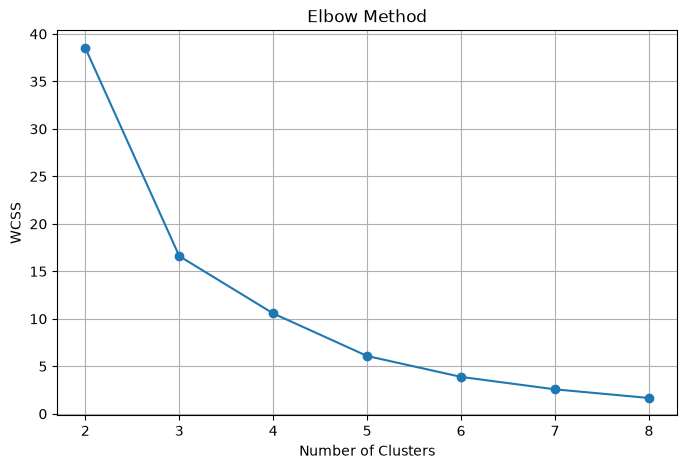

In [179]:
# Elbow Method

wcss = []

for k in range(2,9):

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=20

    )

    model.fit(X)

    wcss.append(model.inertia_)
plt.figure(figsize=(8,5))

plt.plot(

    range(2,9),

    wcss,

    marker="o"

)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)
plt.savefig("Chart of Elbow Method.png", dpi=300, bbox_inches="tight")
plt.show()

In [180]:
# Best Cluster

# Assume elbow occurs at 4.

kmeans = KMeans(

    n_clusters=4,

    random_state=42,

    n_init=20

)

cluster_data["Cluster"] = kmeans.fit_predict(X)

In [181]:
# Evaluate Clustering
score = silhouette_score(

    X,

    cluster_data["Cluster"]

)

print("Silhouette Score :",round(score,3))

Silhouette Score : 0.425


In [182]:
# PCA Visualization
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X)

cluster_data["PC1"] = pca_data[:,0]

cluster_data["PC2"] = pca_data[:,1]

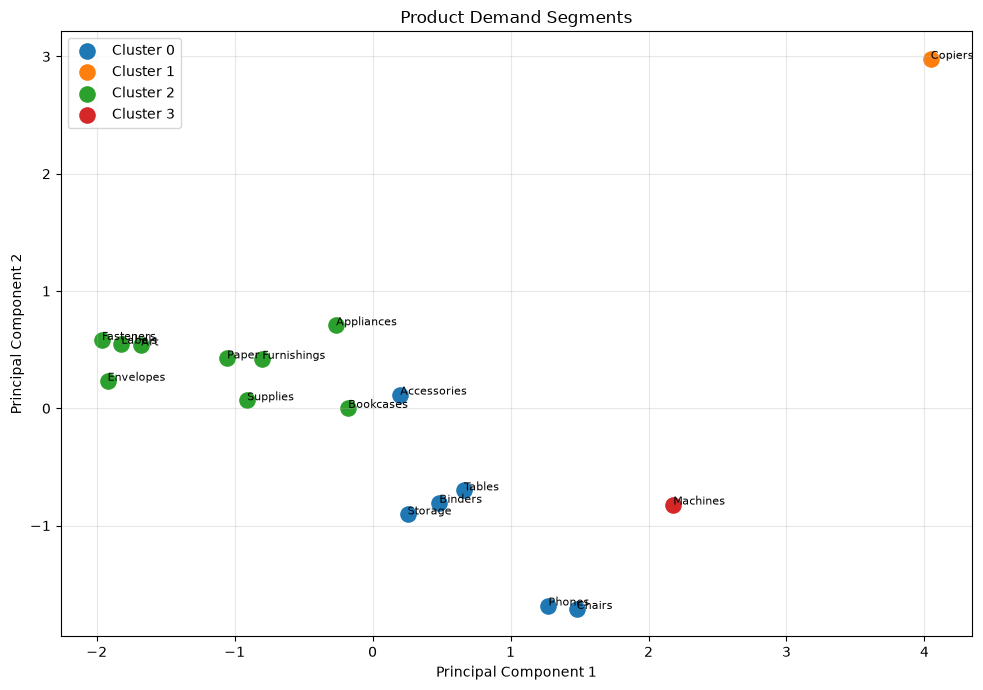

In [184]:
# Cluster Plot
plt.figure(figsize=(10,7))

for cluster in sorted(cluster_data["Cluster"].unique()):

    temp = cluster_data[
        cluster_data["Cluster"]==cluster
    ]

    plt.scatter(

        temp["PC1"],

        temp["PC2"],

        s=120,

        label=f"Cluster {cluster}"

    )

    for _, row in temp.iterrows():

        plt.text(

            row["PC1"],

            row["PC2"],

            row["Sub-Category"],

            fontsize=8

        )

plt.title("Product Demand Segments")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(alpha=.3)

plt.legend()
plt.tight_layout()
plt.savefig("Chart of Product Demand Segments.png", dpi=300, bbox_inches="tight")
plt.show()

In [185]:
# Label the Clusters

# Automatically generate meaningful names.

summary = (

    cluster_data

    .groupby("Cluster")[

        [

            "Total Sales",

            "Growth Rate",

            "Sales Volatility"

        ]

    ]

    .mean()

)

summary



cluster_labels = {

    0:"High Volume, Stable Demand",

    1:"Growing Demand",

    2:"Low Volume, High Volatility",

    3:"Declining Demand"

}

cluster_data["Demand Segment"] = (

    cluster_data["Cluster"]

    .map(cluster_labels)

)

In [186]:
# Final Segmentation Table
cluster_data[

[
"Sub-Category",

"Demand Segment",

"Total Sales",

"Growth Rate",

"Sales Volatility",

"Average Order Value"

]

].sort_values("Demand Segment")

,Sub-Category,Demand Segment,Total Sales,Growth Rate,Sales Volatility,Average Order Value
11,Machines,Declining Demand,189238.6310,-29.793120,5603.554747,1645.553313
6,Copiers,Growing Demand,146248.0940,479.729510,5500.774391,2215.880212
0,Accessories,"High Volume, Stable Demand",164186.7000,145.055961,2579.994809,217.178175
14,Storage,"High Volume, Stable Demand",219343.3920,38.366108,2822.084310,263.633885
13,Phones,"High Volume, Stable Demand",327782.4480,35.557607,4052.718221,374.180877
16,Tables,"High Volume, Stable Demand",202810.6280,33.078016,3224.082504,645.893720
3,Binders,"High Volume, Stable Demand",200028.7850,65.778638,3848.223648,134.067550
5,Chairs,"High Volume, Stable Demand",322822.7310,20.954677,4407.232960,531.833165
4,Bookcases,"Low Volume, High Volatility",113813.1987,49.846598,2220.405080,503.598224
7,Envelopes,"Low Volume, High Volatility",16128.0460,-12.121345,228.218688,65.032444


## Stocking Strategy

### High Volume, Stable Demand

##### These products sell consistently throughout the year and contribute significantly to overall sales. Since the demand is stable, the company should keep sufficient stock available and replenish inventory regularly. This helps avoid stock shortages and ensures customers can always find these products.

### Growing Demand

##### Products in this group are becoming more popular over time. The business should gradually increase inventory for these products while continuing to monitor sales trends. If demand continues to rise, additional stock can be ordered to meet future customer needs.

### Low Volume, High Volatility

##### Demand for these products changes frequently, making them difficult to predict. Instead of keeping large amounts of inventory, the company should maintain a limited stock with a small safety buffer. Regular monitoring will help prevent both stock shortages and unnecessary inventory costs.

### Declining Demand

##### These products have shown a decrease in demand over time. The company should reduce inventory levels and avoid placing large purchase orders. Promotions, discounts, or clearance sales can be used to sell existing stock and free up warehouse space for products with higher demand.